**Laboratorio 2 - Diego Andrés Escobedo Moran**

**Ejercicio 1:**

Análisis Exploratorio de Datos (EDA) usando Pandas

* Análisis del tipo de datos que se tiene en el dataset

In [0]:
# Supongamos que el DataFrame se llama df
display(df.dtypes)

x            float64
y            float64
categoria     object
dtype: object

* Análisis de variables cuantitativas

In [0]:
# Análisis de variables cuantitativas
quantitative_vars = df.select_dtypes(include=['number'])
display(quantitative_vars.describe())

x,y
100.0,100.0
0.5261691937113454,0.48693092279963496
0.2938142854653545,0.27664235200669196
0.0324844186006481,9.182409592445318E-4
0.3003708848802078,0.2511788976003417
0.510271950688195,0.45040197389955877
0.7934605724521643,0.7381587983025218
0.9987966700921728,0.9833539205333214


* Análisis de variables cualitativas

In [0]:
# Análisis de variables cualitativas
qualitative_vars = df.select_dtypes(include=['object', 'category'])

# Resumen de frecuencias para cada variable cualitativa
for col in qualitative_vars.columns:
    display(qualitative_vars[col].value_counts())
    display(qualitative_vars[col].value_counts(normalize=True))

categoria
A    36
C    35
B    29
Name: count, dtype: int64

categoria
A    0.36
C    0.35
B    0.29
Name: proportion, dtype: float64

**¿Cómo se relaciona este análisis con las metodologías vistas en clase (DLM, DL, CRISP-DM)?**

El EDA permite comprender los datos antes de analizarlos en profundidad. En CRISP-DM, forma parte de la etapa de Data Understanding, donde se exploran y evalúan los datos. En DLM, contribuye a asegurar la calidad y utilidad de los datos dentro de su ciclo de vida. En Data Literacy (DL), ayuda a desarrollar la capacidad de interpretar datos y tomar decisiones informadas.

**Ejercicio 2:**

Crear gráficos usando paquetes de python (matplotlib, seaborn, etc)

* Crear un diagrama de dispersión (scatter plot)

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


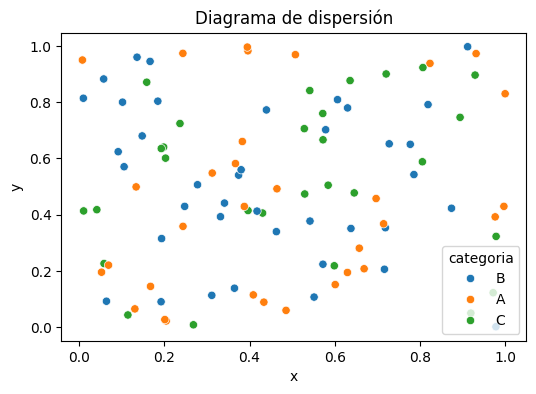

In [0]:
%pip install matplotlib seaborn

import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplo de datos
import numpy as np
import pandas as pd

df = pd.DataFrame({
    'x': np.random.rand(100),
    'y': np.random.rand(100),
    'categoria': np.random.choice(['A', 'B', 'C'], 100)
})

# Diagrama de dispersión
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='x', y='y', hue='categoria')
plt.title('Diagrama de dispersión')
plt.show()

* Crear un gráfico de barras (bar plot)

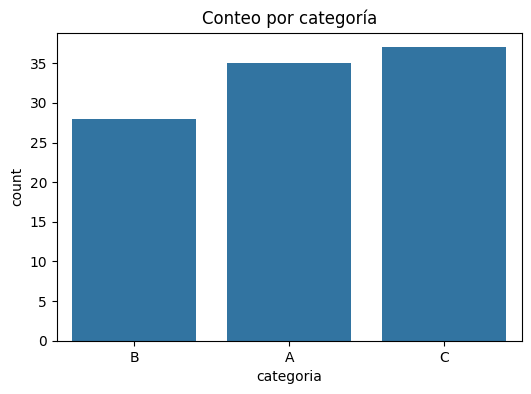

In [0]:
# Gráfico de barras: conteo por categoría
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='categoria')
plt.title('Conteo por categoría')
plt.show()

* Crear un histograma (histogram)

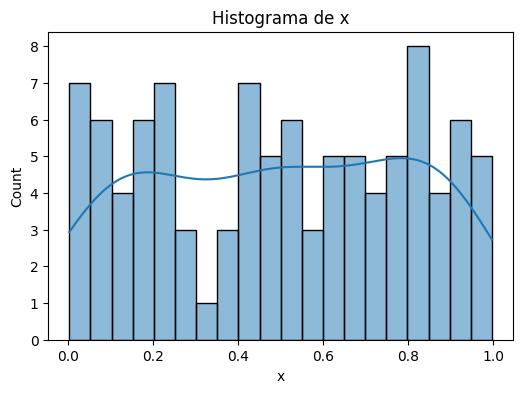

In [0]:
# Histograma de la variable 'x'
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='x', bins=20, kde=True)
plt.title('Histograma de x')
plt.show()

**¿Cómo se podría identificar el tipo de gráfico ideal para presentar información de un dataset?**

El tipo de gráfico adecuado depende del tipo de datos y del objetivo del análisis. Primero, es importante identificar si los datos son numéricos o categóricos, y luego definir que se desea mostrar. 

Si se busca analizar la relación entre dos variables numéricas, un diagrama de dispersión (scatter plot) es el más adecuado. Para comparar valores diferentes entre categorías, se recomienda utilizar un gráfico de barras (bar plot). Por otro lado, si el objetivo es entender cómo se distribuyen los datos, un histograma es la mejor opción.

En general, la elección del gráfico debe facilitar la interpretación de la información y comunicar los resultados de forma clara y efectiva

**Ejercicio 3**

Complementar análisis numérico con gráficos en un dataset.

* Análisis de variables cuantitativas con su respectivo gráfico (histograma, dispersión)

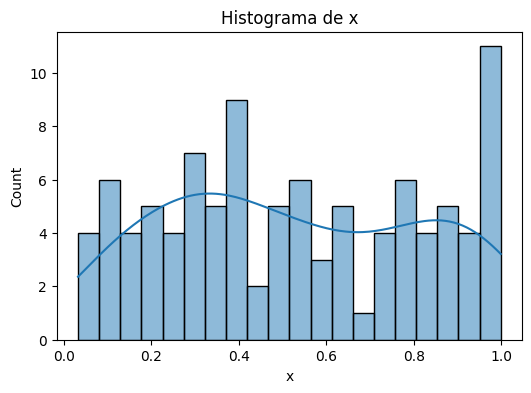

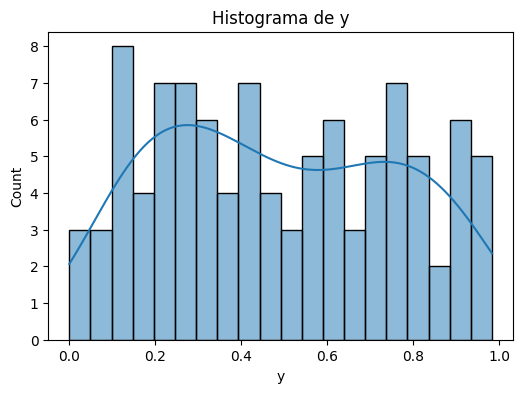

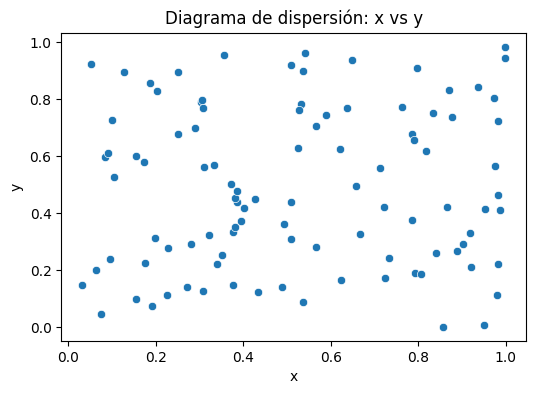

In [0]:
# Análisis de variables cuantitativas con gráficos

# Histograma para cada variable cuantitativa
for col in quantitative_vars.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data=quantitative_vars, x=col, bins=20, kde=True)
    plt.title(f'Histograma de {col}')
    plt.show()

# Diagramas de dispersión para cada par de variables cuantitativas
from itertools import combinations

for x_col, y_col in combinations(quantitative_vars.columns, 2):
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=quantitative_vars, x=x_col, y=y_col)
    plt.title(f'Diagrama de dispersión: {x_col} vs {y_col}')
    plt.show()

* Análisis de variables cualitativas con su respectivo gráfico (barras, pieI)

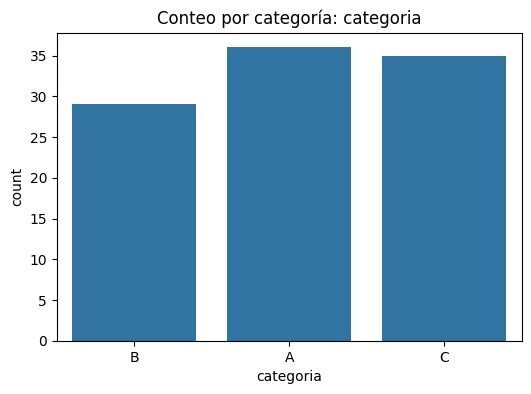

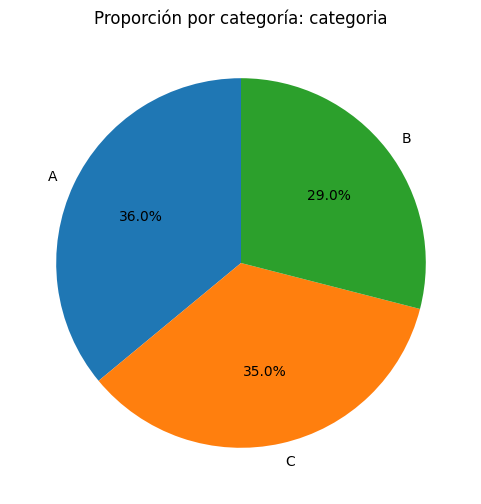

In [0]:
# Análisis de variables cualitativas con gráficos de barras y pastel

for col in qualitative_vars.columns:
    # Gráfico de barras
    plt.figure(figsize=(6,4))
    sns.countplot(data=qualitative_vars, x=col)
    plt.title(f'Conteo por categoría: {col}')
    plt.show()
    
    # Gráfico de pastel
    plt.figure(figsize=(6,6))
    qualitative_vars[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Proporción por categoría: {col}')
    plt.ylabel('')
    plt.show()

**¿Tendría sentido incluir un Análisis Exploratorio de Datos en un pipeline de datos?**

Sí, tiene sentido incluir el Análisis Exploratorio de Datos dentro de un pipeline, especialmente en sus primeras etapas. El EDA permite comprender la estructura, calidad y comportamiento de los datos, lo que ayuda a detectar errores, valores faltantes o inconsistencias antes de procesarlos.

Además, el EDA facilita tomar decisiones sobre cómo limpiar, transformar y utilizar los datos de manera adecuada. Sin este análisis, el pipeline podría trabajar con datos incorrectos o mal interpretados, afectando los resultados finales.

**Ejercicio 4**

Manejo de metadata

* Uso de la línea de comandos para ver metadata

In [0]:
# Ver metadata del DataFrame usando info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   x          100 non-null    float64
 1   y          100 non-null    float64
 2   categoria  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


* Uso de Python para extraer metadata de un paquete

In [0]:
import importlib.metadata

# Extraer metadata del paquete 'seaborn'
metadata = importlib.metadata.metadata('seaborn')
for key in ['Name', 'Version', 'Summary', 'Author', 'License']:
    print(f"{key}: {metadata.get(key)}")

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Author: None
License: None


**¿Cómo beneficiaría un buen manejo de metadata a un pipeline de datos?**

Un buen manejo de metadata mejora significativamente un pipeline de datos, ya que permite entender el origen, estructura y significado de la información que se está procesando. Esto facilita la organización de los datos, la detección de errores y la trazabilidad a lo largo del pipeline.

Además, los metadatos ayudan a mantener consistencia entre diferentes etapas del proceso, permiten que otros usuarios comprendan los datos más fácilmente y mejoran la calidad del análisis final. En general, hacen que el pipeline sea más confiable, eficiente y fácil de mantener.

**Resumen de la práctica**

En este laboratorio se realizó un Análisis Exploratorio de Datos (EDA), donde se identificaron los tipos de datos, se analizaron variables cuantitativas mediante estadísticas descriptivas y variables cualitativas a través de frecuencias. Además, se complementó el análisis numérico con visualizaciones para facilitar la interpretación de los datos.

Luego se trabajaron diferentes conceptos fundamentales del análisis de datos utilizando herramientas como Python, Pandas, matplotlib y seaborn. Se inició con la creación de gráficos básicos como diagramas de dispersión, gráficos de barras e histogramas, con el objetivo de representar visualmente la información de un dataset.

También se abordó el manejo de metadata, tanto desde la línea de comandos como con Python, entendiendo su importancia para describir, organizar y dar contexto a los datos. Finalmente, se creó una página de portafolio utilizando GitHub, donde se integraron los proyectos y actividades desarrolladas durante la práctica.

Conclusiones

* El uso de gráficos es esencial para interpretar datos de forma clara y facilitar la toma de decisiones.
* El Análisis Exploratorio de Datos permite comprender la estructura, calidad y comportamiento de un dataset antes de aplicar modelos más avanzados.
* El manejo de metadata mejora la organización, trazabilidad y confiabilidad de los datos dentro de un pipeline.
* Integrar estos elementos en un portafolio permite evidenciar el aprendizaje y documentar el progreso en el área de análisis de datos.
* En conjunto, estas herramientas y metodologías ayudan a construir un proceso de análisis más estructurado y efectivo.